# Model Training Notebook

This notebook trains multiple regression models for **Price prediction** where the target is **already log-transformed**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
DATA_PATH = Path("../data/processed/main/feature_engineered.csv")
TARGET_COL = "ttm_avg_rate"
LEAK_COL = "ttm_revenue"
df = pd.read_csv(DATA_PATH)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in data.")

df = df.dropna(subset=[TARGET_COL]).copy()

drop_cols = [TARGET_COL]
if LEAK_COL in df.columns:
    drop_cols.append(LEAK_COL)

X = df.drop(columns=drop_cols)
y = df[TARGET_COL]
X = X.select_dtypes(include=[np.number, "bool"]).astype(float)

zone_cols = [
    "geographic_zone_Asia Pacific",
    "geographic_zone_Europe",
    "geographic_zone_Northern America",
    "geographic_zone_Africa",
    "geographic_zone_Latin America",
    "geographic_zone_Middle East",
]
df["zone"] = df[zone_cols].idxmax(axis=1)
{"data_shape": df.shape, "feature_shape": X.shape, "target": TARGET_COL}

{'data_shape': (37643, 63),
 'feature_shape': (37643, 60),
 'target': 'ttm_avg_rate'}

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=df["zone"],
    random_state=42,
)
{"train_shape": X_train.shape, "test_shape": X_test.shape}

{'train_shape': (30114, 60), 'test_shape': (7529, 60)}

In [4]:
# Main Model Training Pipeline
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42)),
    ]),
    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.0005, max_iter=10000, random_state=42)),
    ]),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=12,
        min_samples_leaf=10,
        random_state=42,
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=180,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42,
    ),
    "Support Vector Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVR(C=1.0, epsilon=0.1, max_iter=10000, random_state=42)),
    ]),
    "Neural Network Regressor": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.0001,
                batch_size=256,
                learning_rate_init=0.001,
                max_iter=200,
                early_stopping=True,
                n_iter_no_change=15,
                random_state=42,
            ),
        ),
    ]),
}
if HAS_XGBOOST:
    models["XGBoost Regressor"] = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )
stacking_estimators = [
    (
        "ridge",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0, random_state=42)),
        ]),
    ),
    (
        "rf",
        RandomForestRegressor(
            n_estimators=120,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=1,
            random_state=42,
        ),
    ),
]
if HAS_XGBOOST:
    stacking_estimators.append(
        (
            "xgb",
            XGBRegressor(
                n_estimators=120,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=1,
            ),
        )
    )

models["Stacking Ensemble"] = StackingRegressor(
    estimators=stacking_estimators,
    final_estimator=Ridge(alpha=1.0, random_state=42),
    passthrough=False,
    n_jobs=-1,
)

results = []
predictions = {}
trained_models = {}

for model_name, estimator in models.items():
    estimator.fit(X_train, y_train)
    train_pred = estimator.predict(X_train)
    test_pred = estimator.predict(X_test)
    results.append(
        {
            "model": model_name,
            "train_r2": r2_score(y_train, train_pred),
            "test_r2": r2_score(y_test, test_pred),
            "train_rmse": np.sqrt(mean_squared_error(y_train, train_pred)),
            "test_rmse": np.sqrt(mean_squared_error(y_test, test_pred)),
            "train_mae": mean_absolute_error(y_train, train_pred),
            "test_mae": mean_absolute_error(y_test, test_pred),
        }
    )
    predictions[model_name] = test_pred
    trained_models[model_name] = estimator

results_df = pd.DataFrame(results).sort_values("test_rmse").reset_index(drop=True)
results_df

c:\Users\RUSHIKESH\Projects\Airbnb Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,model,train_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae
0,Stacking Ensemble,0.9343,0.8244,0.2091,0.3445,0.1539,0.2577
1,Random Forest Regressor,0.9628,0.8211,0.1574,0.3478,0.1095,0.2576
2,XGBoost Regressor,0.8513,0.8174,0.3147,0.3514,0.2402,0.2673
3,Neural Network Regressor,0.8134,0.7467,0.3525,0.4138,0.2708,0.3140
4,Decision Tree Regressor,0.7979,0.7109,0.3668,0.4421,0.2774,0.3350
5,Lasso Regression,0.6338,0.6434,0.4938,0.4910,0.3848,0.3844
6,Ridge Regression,0.6338,0.6432,0.4938,0.4911,0.3848,0.3846
7,Linear Regression,0.6338,0.6432,0.4938,0.4911,0.3848,0.3846
8,Support Vector Regressor,0.6318,0.6420,0.4952,0.4920,0.3835,0.3831


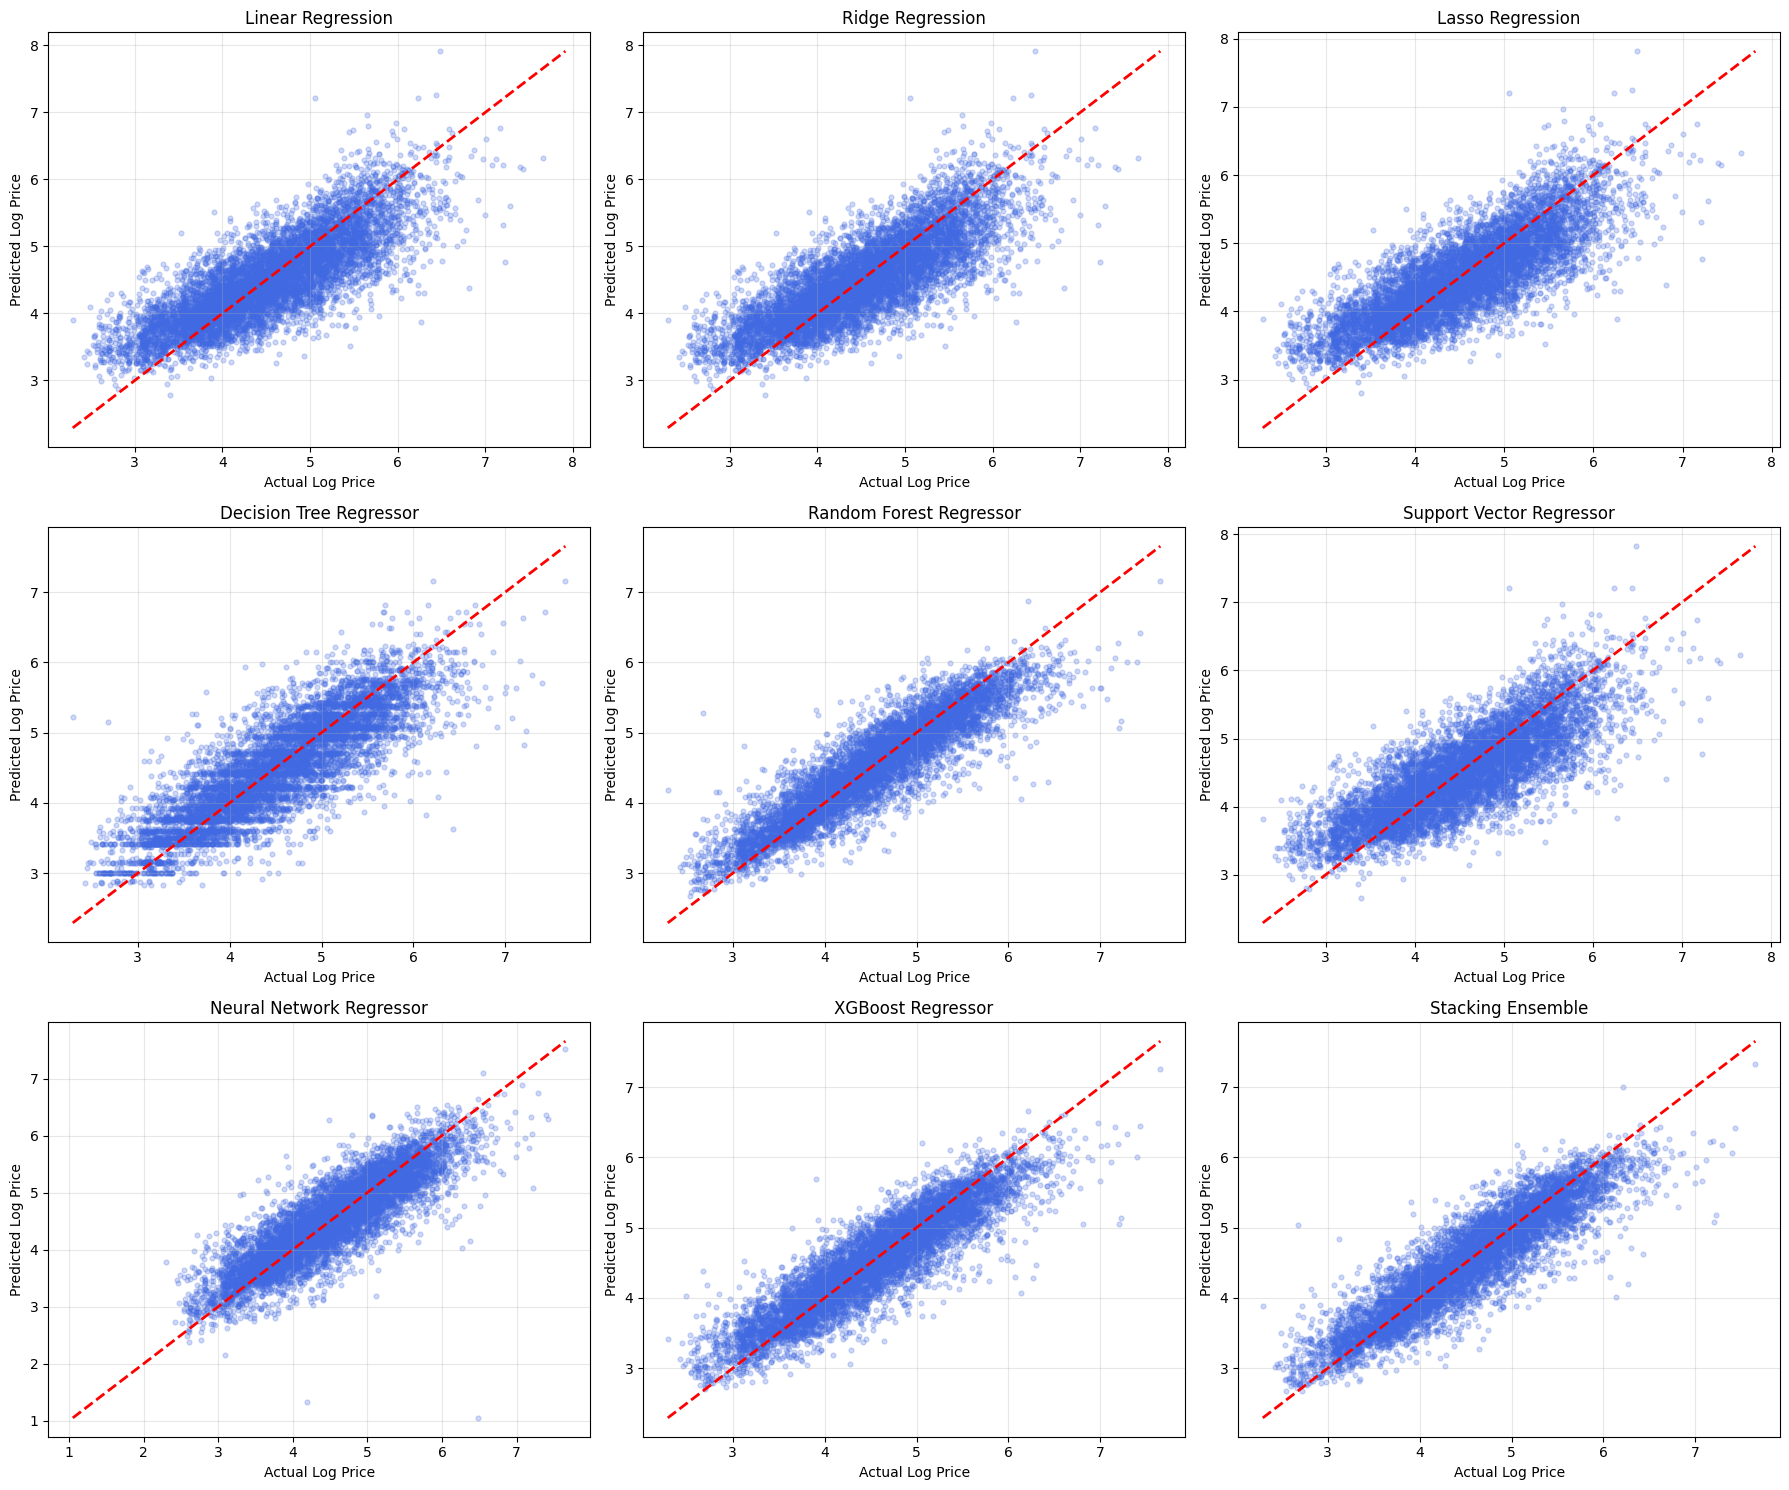

In [5]:
n_models = len(predictions)
cols = 3
rows = int(np.ceil(n_models / cols))
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.atleast_1d(axes).flatten()

y_test_arr = np.asarray(y_test)

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    y_pred_arr = np.asarray(y_pred)

    min_val = float(min(y_test_arr.min(), y_pred_arr.min()))
    max_val = float(max(y_test_arr.max(), y_pred_arr.max()))

    ax.scatter(y_test_arr, y_pred_arr, alpha=0.25, s=12, color="royalblue")
    ax.plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
    ax.set_title(model_name)
    ax.set_xlabel("Actual Log Price")
    ax.set_ylabel("Predicted Log Price")
    ax.grid(alpha=0.3)

for idx in range(n_models, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [6]:
baseline_metrics_df = results_df.copy()
hp_results = globals().get("hp_search_results", [])
hp_models = globals().get("hp_search_models", {})

metrics_frames = [baseline_metrics_df]
if len(hp_results) > 0:
    tuned_metrics_df = pd.DataFrame([result.__dict__ for result in hp_results])
    tuned_metrics_df["source"] = "tuned"
    metrics_frames.append(tuned_metrics_df)

all_model_metrics_df = pd.concat(metrics_frames, ignore_index=True)
all_model_metrics_df["overfit_gap"] = (all_model_metrics_df["train_r2"] - all_model_metrics_df["test_r2"]).abs()
eligible_models_df = all_model_metrics_df[all_model_metrics_df["test_r2"] >= 0.75].copy()
if eligible_models_df.empty:
    eligible_models_df = all_model_metrics_df.copy()
eligible_models_df = eligible_models_df.sort_values(
    ["test_rmse", "test_mae", "overfit_gap", "test_r2"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

best_row = eligible_models_df.iloc[0]
best_model_name = best_row["model"]

if best_model_name in trained_models:
    best_model = trained_models[best_model_name]
elif best_model_name in hp_models:
    best_model = hp_models[best_model_name]
else:
    raise KeyError(f"Could not find fitted model object for: {best_model_name}")

all_model_metrics_df.sort_values(["test_rmse", "test_mae"]).reset_index(drop=True)

,model,train_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,overfit_gap
0,Stacking Ensemble,0.9343,0.8244,0.2091,0.3445,0.1539,0.2577,0.1099
1,Random Forest Regressor,0.9628,0.8211,0.1574,0.3478,0.1095,0.2576,0.1417
2,XGBoost Regressor,0.8513,0.8174,0.3147,0.3514,0.2402,0.2673,0.0339
3,Neural Network Regressor,0.8134,0.7467,0.3525,0.4138,0.2708,0.3140,0.0667
4,Decision Tree Regressor,0.7979,0.7109,0.3668,0.4421,0.2774,0.3350,0.0870
5,Lasso Regression,0.6338,0.6434,0.4938,0.4910,0.3848,0.3844,0.0096
6,Ridge Regression,0.6338,0.6432,0.4938,0.4911,0.3848,0.3846,0.0094
7,Linear Regression,0.6338,0.6432,0.4938,0.4911,0.3848,0.3846,0.0094
8,Support Vector Regressor,0.6318,0.6420,0.4952,0.4920,0.3835,0.3831,0.0103


In [7]:
import joblib
import pickle
from pathlib import Path
import json

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

try:
    from xgboost import XGBRegressor
    if isinstance(best_model, XGBRegressor):
        model_save_path = models_dir / "best_ttm_avg_rate_model.json"
        best_model.get_booster().save_model(str(model_save_path))
        model_format = "XGBoost JSON (native)"
    else:
        model_save_path = models_dir / "best_ttm_avg_rate_model.pkl"
        joblib.dump(best_model, model_save_path, protocol=pickle.HIGHEST_PROTOCOL)
        model_format = "joblib pickle"
except ImportError:
    model_save_path = models_dir / "best_ttm_avg_rate_model.pkl"
    joblib.dump(best_model, model_save_path, protocol=pickle.HIGHEST_PROTOCOL)
    model_format = "joblib pickle"

feature_list_path = models_dir / "best_ttm_avg_rate_features.txt"
with open(feature_list_path, "w") as f:
    f.write("# Features used for selected TTM Average Rate model\n")
    f.write(f"# Model: {best_model_name}\n")
    f.write(f"# Format: {model_format}\n")
    f.write("# Selection criteria: test_r2 >= 0.75, then low RMSE/MAE, then low overfit gap\n")
    f.write(f"# Test RMSE (log scale): {best_row['test_rmse']:.4f}\n")
    f.write(f"# Test MAE (log scale): {best_row['test_mae']:.4f}\n")
    f.write(f"# Test R2: {best_row['test_r2']:.4f}\n")
    f.write(f"# Train R2: {best_row['train_r2']:.4f}\n")
    f.write(f"# Overfit Gap: {best_row['overfit_gap']:.4f}\n\n")
    for i, col in enumerate(X.columns, 1):
        f.write(f"{i}. {col}\n")

metrics_csv_path = models_dir / "all_price_model_metrics.csv"
metrics_json_path = models_dir / "all_price_model_metrics.json"

metrics_to_save = all_model_metrics_df.sort_values(
    ["test_rmse", "test_mae", "overfit_gap", "test_r2"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

metrics_to_save.to_csv(metrics_csv_path, index=False)
metrics_to_save.to_json(metrics_json_path, orient="records", indent=2)

registry_path = models_dir / "model_registry.json"
registry = {}
if registry_path.exists():
    with open(registry_path, "r") as f:
        registry = json.load(f)

if "models" not in registry:
    registry["models"] = {}

registry["models"]["best_ttm_avg_rate"] = {
    "model_file": model_save_path.name,
    "model_format": model_format,
    "features_file": feature_list_path.name,
    "metrics_files": {
        "all_models_csv": metrics_csv_path.name,
        "all_models_json": metrics_json_path.name,
    },
    "selection_criteria": {
        "min_test_r2": 0.75,
        "priority_order": ["test_rmse", "test_mae", "overfit_gap"],
    },
    "metrics": {
        "test_rmse": float(best_row["test_rmse"]),
        "test_mae": float(best_row["test_mae"]),
        "test_r2": float(best_row["test_r2"]),
        "train_r2": float(best_row["train_r2"]),
        "train_rmse": float(best_row["train_rmse"]),
        "train_mae": float(best_row["train_mae"]),
        "overfit_gap": float(best_row["overfit_gap"]),
        "target_transform": "log1p",
        "target_column": TARGET_COL,
    },
    "model_name": best_model_name,
    "feature_count": len(X.columns),
    "training_date": pd.Timestamp.now().isoformat(),
}

with open(registry_path, "w") as f:
    json.dump(registry, f, indent=2)

{
    "selected_model": best_model_name,
    "model_path": str(model_save_path),
    "metrics_csv": str(metrics_csv_path),
    "metrics_json": str(metrics_json_path),
    "registry": str(registry_path),
}

{'selected_model': 'Stacking Ensemble',
 'model_path': '..\\models\\best_ttm_avg_rate_model.pkl',
 'metrics_csv': '..\\models\\all_price_model_metrics.csv',
 'metrics_json': '..\\models\\all_price_model_metrics.json',
 'registry': '..\\models\\model_registry.json'}